# 13 — ResNets and Neural ODEs

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

> **Central question.** *When is a residual network a discretized controlled ODE, and how does the adjoint method of control compute its gradient exactly?*

The data point becomes an **initial state**, the network's parameters become a **control**, and a forward pass becomes a **trajectory**. Once training is written as an optimal control problem, the adjoint method of [notebook 07](07_adjoints_density_heat_control.ipynb) computes its gradient — and it turns out to be exactly backpropagation. Along the way we build the numerical ODE solvers used throughout the course, learn a chaotic dynamics from data, and watch a trained flow deform the plane until two classes separate.

### Table of Contents

1. **A residual network is an Euler scheme** — layers as time steps, two ways to add layers
2. **Solving ODEs numerically** — Euler and Runge–Kutta, tested on the Lorenz system
3. **The error of Euler's method at a fixed horizon** — order one, proved and measured
4. **Training as simultaneous optimal control** — one control for all samples
5. **The discrete adjoint: backpropagation is the adjoint method** — derived, then verified against central differences
6. **Laboratory: learning a dynamics from trajectories** — a neural ODE recovers the Lorenz field
7. **Laboratory: a residual classifier for E6** — classification as simultaneous control, with a frozen protocol
8. **Learning representations** — the flow deforms the plane until a line suffices
9. **Control ↔ ML**
10. **Common misconceptions**
11. **The continuous adjoint, and order preservation in one dimension**
12. **Turnpike and momentum: two research directions**
13. **Key takeaways**
14. **Exercises**

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import plotting as P           # the course palette, the house style, and the figure helpers

torch.manual_seed(0)
rng = np.random.default_rng(0);

## Where are we?

> **Recap.** [Notebook 07](07_adjoints_density_heat_control.ipynb), §2: one state solve forward, one adjoint solve backward, and their combination give the whole gradient of a cost, whatever the number of controls. [Notebook 12](12_shallow_networks.ipynb): a neuron $w\,\sigma(a\cdot x+b)$, and networks that are linear in some parameters and nonlinear in others.

Three formulas stand side by side: a **neural ODE** $x'(t)=w(t)\,\sigma(a(t)\cdot x(t)+b(t))$, its Euler discretization $x_{k+1}=x_k+h\,w_k\sigma(a_k\cdot x_k+b_k)$, and the shallow network $\sum_jw_j\sigma(a_j\cdot x+b_j)$ of notebook 12. This notebook studies the first two and the bridge between them.

**Notation.** $\Theta$ is the full parameter set; $\theta_k=(W_k,A_k,b_k)$ the parameters of layer $k$. From this notebook on, $w$ (a column of $W$) is the outer weight of a neuron of the vector field, not the parameter vector of notebooks 09–11. The number of layers is $K$ and the Lipschitz constant of the field is $L_f$.

## 1. A residual network is an Euler scheme

**The vector field.** A neuron in $\mathbb R^d$ is $w\,\sigma(a\cdot x+b)$, with outer weight $w\in\mathbb R^d$ (the direction of the field), inner weight $a\in\mathbb R^d$ and bias $b\in\mathbb R$. With $P$ neurons,
$$
f(x,\theta)=\sum_{j=1}^Pw_j\,\sigma(a_j\cdot x+b_j)=W\sigma(Ax+b),\qquad\theta=(W,A,b),
$$
where the columns of $W\in\mathbb R^{d\times P}$ are the $w_j$, the rows of $A\in\mathbb R^{P\times d}$ are the $a_j$, and $\sigma$ acts entrywise. In this notebook $\sigma=\tanh$ unless stated, because the gradient checks of §5 need a differentiable field; the ReLU appears in notebook 14.

**The neural ODE and its Euler scheme.** For a control $t\mapsto\theta(t)$ on $[0,T]$ and an input $x_0$,
$$
x'(t)=f(x(t),\theta(t)),\quad x(0)=x_0;\qquad\qquad x_{k+1}=x_k+h\,f(x_k,\theta_k),\quad k=0,\dots,K-1,\quad T=Kh.
$$
The second formula is a **residual network** (ResNet) with $K$ layers: each layer adds a correction to its input instead of replacing it. Residual networks made it possible to train much deeper networks than before (He et al., 2016), and reading their layers as time steps of an ODE (Chen et al., 2018; E, 2017) is the starting point of this part of the course. The map $x_0\mapsto x_K$ approximates the **flow map** $\Phi_T:x_0\mapsto x(T)$. A control that is constant on each layer and jumps between layers is piecewise constant: *each time discontinuity is one change of layer*.

**Two ways to add layers.** The formula $T=Kh$ hides a choice.

- **Refinement at a fixed horizon:** $K\to2K$, $h\to h/2$, with the new layers sampling the *same* control $\theta(t)$. The network approximates one fixed flow map $\Phi_T$ better and better (§3). This is the sense in which a deep ResNet "is" a neural ODE.
- **A longer horizon at a fixed step:** $K\to2K$ with $h$ fixed, so $T\to2T$. The network now approximates a *different* map, the flow over a longer time. Errors are not reduced, and the error bound of §3 grows with $T$. This is the long-horizon reading of [notebook 08](08_long_time_control_turnpike.ipynb).

A trained ResNet need not be either: nothing forces its layer parameters $\theta_k$ to vary regularly with $k$. The ODE reading is a modelling choice that becomes accurate when they do.

**At a fixed number of layers, $T$ is not a separate parameter.** In $x_{k+1}=x_k+(T/K)\,W_k\sigma(A_kx_k+b_k)$ only the products $(T/K)W_k$ appear: doubling $T$ and halving every $W_k$ gives the same network. The same holds for the ODE, by the change of time $s=t/T$: *the control time can be made arbitrarily small, absorbed into $\|w\|$ by scaling*. The time horizon matters only together with a bound on the size of the controls, for instance through a regularization term (§4).

## 2. Solving ODEs numerically

Consider the initial value problem
$$
\dot x(t) = f\big(t, x(t)\big), \qquad x(t_0) = x_0.
$$
If $f$ is continuous in $t$ and Lipschitz in $x$, a unique solution exists on a neighborhood of $t_0$ (Picard–Lindelöf). For most vector fields no closed form exists, so we approximate the solution on a time grid $t_0 < t_1 < \dots < t_K$ with step size $h$:

- **Explicit Euler** follows the tangent at the current point: $x_{k+1} = x_k + h\, f(t_k, x_k)$, with accumulated global error $\mathcal{O}(h)$ — this is the residual network of §1.
- **Classical Runge–Kutta (RK4)** evaluates the slope four times per step and combines the evaluations:
$$
k_1 = f(t_k, x_k), \quad
k_2 = f\Big(t_k + \tfrac h2,\, x_k + \tfrac h2 k_1\Big), \quad
k_3 = f\Big(t_k + \tfrac h2,\, x_k + \tfrac h2 k_2\Big), \quad
k_4 = f(t_k + h,\, x_k + h k_3),
$$
$$
x_{k+1} = x_k + \frac h6\big(k_1 + 2k_2 + 2k_3 + k_4\big),
$$
with global error $\mathcal{O}(h^4)$. This is the `odeint` that notebooks 00–08 used as a black box; here it stops being one.

As a test problem we take the **Lorenz system** (Lorenz, 1963)
$$
\begin{cases}\dot x_1 = \sigma (x_2 - x_1), \\ \dot x_2 = x_1 (\rho - x_3) - x_2, \\ \dot x_3 = x_1 x_2 - \beta x_3,\end{cases}
$$
with the classical parameters $\sigma = 10$, $\rho = 28$, $\beta = 8/3$, for which the dynamics are chaotic: a harsh test, since small integration errors grow exponentially.

In [2]:
def euler_step(f, t, x, h):
    return x + h * f(t, x)

def rk4_step(f, t, x, h):
    k1 = f(t, x)
    k2 = f(t + h / 2, x + h / 2 * k1)
    k3 = f(t + h / 2, x + h / 2 * k2)
    k4 = f(t + h, x + h * k3)
    return x + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint(f, x0, ts, step=rk4_step):
    # trajectory x(t_0), ..., x(t_K), stacked along the first axis (torch, so it stays differentiable)
    xs = [x0]
    for t0, t1 in zip(ts[:-1], ts[1:]):
        xs.append(step(f, t0, xs[-1], t1 - t0))
    return torch.stack(xs)

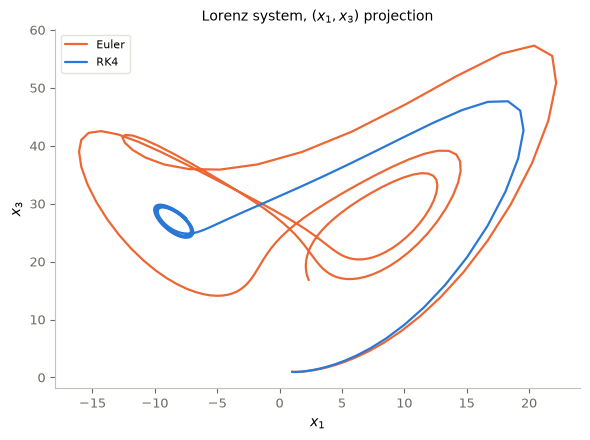

In [3]:
SIGMA, RHO, BETA = 10.0, 28.0, 8.0 / 3.0

def f_lorenz(t, x):
    x1, x2, x3 = x[..., 0], x[..., 1], x[..., 2]
    return torch.stack([SIGMA * (x2 - x1), x1 * (RHO - x3) - x2, x1 * x2 - BETA * x3], dim=-1)

x0 = torch.tensor([1.0, 1.0, 1.0])
ts = torch.linspace(0, 3, 201)                  # h = 0.02
with torch.no_grad():
    tr_euler = odeint(f_lorenz, x0, ts, euler_step)
    tr_rk4 = odeint(f_lorenz, x0, ts, rk4_step)

fig, ax = P.panels(figsize=(6, 4.5))
P.phase(ax, [tr_euler[:, ::2], tr_rk4[:, ::2]], labels=["Euler", "RK4"], colors=[P.ORANGE, P.BLUE],
        xlabel="$x_1$", ylabel="$x_3$", title="Lorenz system, $(x_1, x_3)$ projection",
        legend={"loc": "upper left"})
plt.show()

**Figure 1.** The Lorenz system integrated with the same step $h=0.02$ by explicit Euler and by RK4. On a chaotic flow the two approximations separate quickly: the first-order method accumulates error much faster at the same step size.

## 3. The error of Euler's method at a fixed horizon

The statement below is classical; its proof is the standard one, written for the setting of this notebook.

> **Proposition (global error of forward Euler).**
> *Assumptions:*
> - **(H1) Lipschitz in the state.** For every control value $\theta$ used, $|f(x,\theta)-f(y,\theta)|\le L_f|x-y|$ for all $x,y$. For $f=W\sigma(Ax+b)$ with $|\sigma'|\le1$ (true for $\tanh$ and for the ReLU), one can take $L_f=\max\|W\|\,\|A\|$ over the layers (spectral norms).
> - **(H2) Regularity in time.** The control is constant on each step $[t_k,t_{k+1})$; its discontinuities lie on mesh points.
> - $B$ bounds $|f|$ along the exact trajectory.
>
> *Conclusion:*
> $$|x_K-x(T)|\le\frac{Bh}{2}\big(e^{L_fT}-1\big).$$
>
> *Interpretation:* at a fixed horizon the error is $O(h)$, but the constant can grow exponentially with $T$.

*Proof.* On a step the field is autonomous, so the local error is
$$
\Big|x(t_{k+1})-x(t_k)-hf(x(t_k),\theta_k)\Big|=\Big|\int_{t_k}^{t_{k+1}}\!\big(f(x(s),\theta_k)-f(x(t_k),\theta_k)\big)ds\Big|\le L_fB\!\int_{t_k}^{t_{k+1}}\!(s-t_k)\,ds=\frac{L_fBh^2}{2},
$$
using $|x(s)-x(t_k)|\le B(s-t_k)$. The error $e_k=|x_k-x(t_k)|$ then satisfies $e_{k+1}\le(1+hL_f)e_k+\frac{L_fB}{2}h^2$ with $e_0=0$. Summing the geometric series, $e_K\le\frac{L_fBh^2}{2}\cdot\frac{(1+hL_f)^K-1}{hL_f}\le\frac{Bh}{2}(e^{L_fT}-1)$, because $1+hL_f\le e^{hL_f}$. $\square$

**About the hypotheses.**
- (H1) is what makes the network a well-posed flow. The ReLU satisfies it even though it is not differentiable: the proof uses only Lipschitz continuity.
- (H2) can be relaxed. If $t\mapsto f(x,\theta(t))$ is Lipschitz in time on each step, the local error gains a term proportional to that constant times $h^2$, and the order is still one.
- If a jump of the control falls *inside* a step, Euler uses the wrong field on part of that step, an error of order $h$ on that single step. With finitely many such jumps the global error is still $O(h)$, with a larger constant (the last lines printed by the laboratory check this). Higher-order methods, however, lose their order (Exercise 5). We keep the jumps on the mesh.
- The bound is a worst case. In the experiment we print it next to the observed error.

**Laboratory 1: one fixed field, nested meshes.** The control is chosen by hand, not trained. It has $P=2$ neurons and is constant on $M=4$ pieces of $[0,2]$. Halving $h$ means doubling the number of Euler steps per piece, so the jumps always lie on the mesh. The reference solution is computed by an adaptive high-order solver (`solve_ivp`, DOP853, tolerance $10^{-12}$), restarted at every jump, so it is independent of the scheme being tested.

> **Predict.** By what factor should the error at $T=2$ shrink each time $h$ is halved? And if instead $h$ is fixed and the horizon is extended, what happens to the error?

L_f <= 1.957,  B <= 1.414
   K        h      error at T    error / h   observed order    bound of the Proposition
   4   0.50000     1.675e-01      0.3350                      1.734e+01
   8   0.25000     7.928e-02      0.3171            1.079     8.672e+00
  16   0.12500     3.877e-02      0.3102            1.032     4.336e+00
  32   0.06250     1.931e-02      0.3089            1.006     2.168e+00
  64   0.03125     9.694e-03      0.3102            0.994     1.084e+00
 128   0.01562     4.859e-03      0.3109            0.997     5.420e-01
 256   0.00781     2.432e-03      0.3113            0.998     2.710e-01
 512   0.00391     1.217e-03      0.3115            0.999     1.355e-01
1024   0.00195     6.086e-04      0.3116            1.000     6.775e-02


h = 0.050: error at T = 2, 4, 6, 8: [0.0155 0.0509 0.2258 0.5399]
h = 0.025: error at T = 2, 4, 6, 8: [0.0078 0.0252 0.1094 0.2885]
jumps inside steps, error / h for K = 62, 126, 254, 510: [1.5994 1.604  1.606  1.607 ]


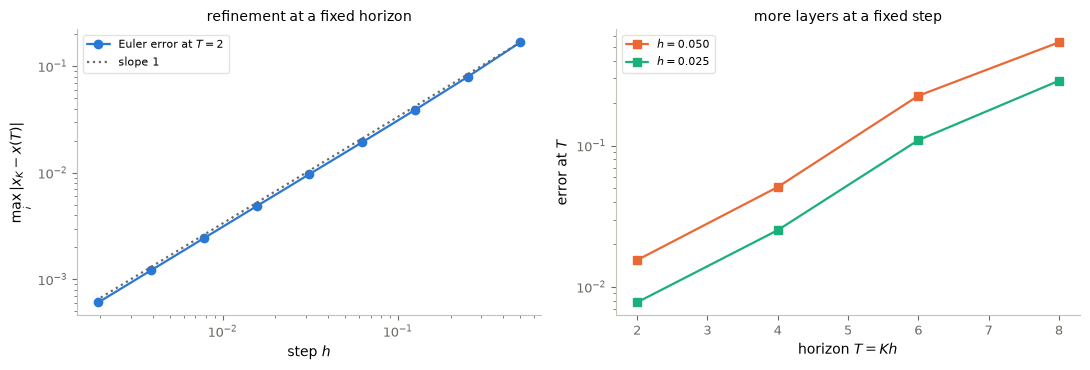

In [4]:
def field(X, W, A, b):
    # f(x) = W tanh(A x + b), evaluated for all rows of X at once:  X (n, d), A (P, d), b (P,), W (d, P)
    return np.tanh(X @ A.T + b) @ W.T

def euler_flow(X0, Theta, h):
    # the ResNet forward pass: all states (K+1, n, d) for the stacked layer parameters Theta = (Ws, As, bs)
    xs = [X0]
    for W, A, b in zip(*Theta):
        xs.append(xs[-1] + h * field(xs[-1], W, A, b))
    return np.array(xs)

def piecewise_constant(pieces, substeps):
    # repeat each piece of a piecewise-constant control `substeps` times: refinement at a fixed horizon
    return tuple(np.repeat(p, substeps, axis=0) for p in pieces)

# A fixed, hand-chosen control, constant on M = 4 pieces of [0, 2]; width P = 2 in R^2.
M, T_fix = 4, 2.0
angles = np.pi * np.arange(M) / M
W_fix = np.stack([[[np.cos(t), -np.sin(t)], [np.sin(t), np.cos(t)]] for t in angles])          # (M, d, P)
A_fix = np.stack([(1 + 0.25 * m) * np.array([[1.0, 0.5], [-0.5, 1.0]]) for m in range(M)])     # (M, P, d)
b_fix = np.stack([(-1) ** m * np.array([0.2, -0.3]) for m in range(M)])                        # (M, P)
pieces_fix = (W_fix, A_fix, b_fix)
X_fix = 0.6 * np.column_stack([np.cos(np.arange(6) * np.pi / 3), np.sin(np.arange(6) * np.pi / 3)])

def reference_flow(X, pieces, piece_length):
    # Adaptive high-order solver, restarted at every jump of the control: independent of the Euler scheme.
    out = []
    for x in X:
        for W, A, b in zip(*pieces):
            x = solve_ivp(lambda t, z: field(z[None], W, A, b)[0], (0, piece_length), x,
                          method="DOP853", rtol=1e-12, atol=1e-13).y[:, -1]
        out.append(x)
    return np.array(out)

def euler_error(pieces, substeps, piece_length, X_ref):
    X_K = euler_flow(X_fix, piecewise_constant(pieces, substeps), piece_length / substeps)[-1]
    return np.linalg.norm(X_K - X_ref, axis=1).max()                  # worst case over the six inputs

x_ref = reference_flow(X_fix, pieces_fix, T_fix / M)
L_f = max(np.linalg.norm(W, 2) * np.linalg.norm(A, 2) for W, A in zip(W_fix, A_fix))
B = max(np.linalg.norm(W, 2) for W in W_fix) * np.sqrt(2)             # |W tanh(.)| <= ||W|| sqrt(P)
substeps = 2 ** np.arange(9)
h_fix = T_fix / (M * substeps)
err_fix = np.array([euler_error(pieces_fix, s, T_fix / M, x_ref) for s in substeps])
print(f"L_f <= {L_f:.3f},  B <= {B:.3f}")
print("   K        h      error at T    error / h   observed order    bound of the Proposition")
for k, (s, h, e) in enumerate(zip(substeps, h_fix, err_fix)):
    order = "" if k == 0 else f"{np.log2(err_fix[k - 1] / e):6.3f}"
    print(f"{M * s:4d}  {h:8.5f}  {e:12.3e}  {e / h:10.4f}   {order:>14s}    {B * h / 2 * np.expm1(L_f * T_fix):10.3e}")

# A longer horizon at a fixed step: the same four pieces repeated periodically, T = 2, 4, 6, 8.
horizons = np.array([2.0, 4.0, 6.0, 8.0])
periodic = {T: tuple(np.concatenate([p] * int(T / T_fix)) for p in pieces_fix) for T in horizons}
x_ref_long = {T: reference_flow(X_fix, periodic[T], T_fix / M) for T in horizons}
err_long = {T_fix / (M * s): [euler_error(periodic[T], s, T_fix / M, x_ref_long[T]) for T in horizons]
            for s in (10, 20)}                                        # h = 0.05 and h = 0.025
for h, errs in err_long.items():
    print(f"h = {h:.3f}: error at T = 2, 4, 6, 8:", np.round(errs, 4))

def euler_misaligned(K):
    # K uniform steps on [0, 2] with K/4 not an integer: every jump of the control falls strictly inside a step.
    h, X = T_fix / K, X_fix.copy()
    for k in range(K):
        m = min(int(k * h / (T_fix / M) + 1e-12), M - 1)              # piece containing the left end of the step
        X = X + h * field(X, W_fix[m], A_fix[m], b_fix[m])
    return np.linalg.norm(X - x_ref, axis=1).max() / h

print("jumps inside steps, error / h for K = 62, 126, 254, 510:",
      np.round([euler_misaligned(K) for K in (62, 126, 254, 510)], 4))

fig, (ax1, ax2) = P.panels(2, figsize=(11.0, 3.8))
ax1.loglog(h_fix, err_fix, "o-", color=P.BLUE, label="Euler error at $T=2$")
ax1.loglog(h_fix, err_fix[0] * h_fix / h_fix[0], ":", color=P.NOTE, label="slope 1")
P.label(ax1, "step $h$", r"$\max_i|x_K-x(T)|$", title="refinement at a fixed horizon")
for (h, errs), c in zip(err_long.items(), (P.ORANGE, P.AQUA)):
    ax2.semilogy(horizons, errs, "s-", color=c, label=f"$h={h:.3f}$")
P.label(ax2, "horizon $T=Kh$", "error at $T$", title="more layers at a fixed step")
plt.show()

**Figure 2.** Forward Euler (a ResNet) for one fixed, hand-chosen piecewise-constant control, against an independent high-accuracy reference. *Left:* the worst error over six inputs at $T=2$, as $h$ is halved with the jumps of the control on the mesh, with a slope-1 guide. *Right:* the error at the final time when the same control is repeated periodically and layers are added at a fixed step, for two step sizes.

*Interpretation (answer to the prediction).* At a fixed horizon the error halves with $h$: the printed observed orders approach $1$ and the ratio error$/h$ settles near a constant, as the Proposition predicts. The printed bound is correct but pessimistic by about two orders of magnitude, because $e^{L_fT}$ is a worst case. When the jumps of the control fall inside steps (last printed line), error$/h$ still settles, at a larger value: the order survives, the constant does not. Adding layers at a fixed step does not reduce the error; it changes the map being approximated, and the error at the final time grows with the horizon, while halving $h$ still halves it at every $T$. "Deeper" means "more accurate" only in the first reading.

## 4. Training as simultaneous optimal control

Given data $\{(x^n,y^n)\}_{n=1}^N$, every input becomes an initial state, and **one** control $\Theta=(\theta_0,\dots,\theta_{K-1})$ must steer all $N$ trajectories at once. This is **simultaneous** (or ensemble) control, the control-theoretic reading of supervised learning. The standard continuous training problem is
$$
\underbrace{\frac1N\sum_{n=1}^N\int_0^T\mathrm{loss}\big(x^n(t),y^n\big)\,dt}_{\text{empirical risk }E(x(\cdot))}\;+\;\alpha\int_0^T\|(a(t),w(t),b(t))\|^2\,dt .
$$
We use its Euler discretization, and allow a terminal cost as well (the loss at the output, the most common choice in practice):
$$
J(\Theta)=\frac1N\sum_{n=1}^N\Big[\Phi_n(x_K^n)+h\sum_{k=0}^{K-1}\ell_n(x_k^n)\Big]+\alpha h\sum_{k=0}^{K-1}|\theta_k|^2,\qquad x_{k+1}^n=x_k^n+hf(x_k^n,\theta_k),\ x_0^n=x^n .
$$
Here $|\theta_k|^2$ is the sum of the squares of all entries of $W_k,A_k,b_k$.

Two details decide whether a gradient computed for this cost is right.

- **The sample average.** The data terms are averaged over $n$, so their gradient is the average of per-sample gradients.
- **The regularization is added once.** It depends on $\Theta$ only, not on the sample. Placing it inside the per-sample sum *without* the average would count it $N$ times. A clean test of both: duplicating every sample must change neither $J$ nor its gradient.

The regularization is a **control cost**, exactly as $\frac12\int|u|^2$ in notebooks 02–08: it prefers small controls, and it is what gives the horizon $T$ a meaning (§1). In machine-learning terms it is an **$L^2$ regularization of the parameters**. Added to the loss, as here, its gradient $2\alpha h\theta_k$ enters the gradient that Adam rescales; this is not the same as the *decoupled* weight decay of AdamW, which shrinks the parameters outside the adaptive rescaling. For plain gradient descent the two coincide up to the step size.

## 5. The discrete adjoint: backpropagation is the adjoint method

**Derivation** *(the discrete analogue of notebook 07, §2)*. Treat each Euler step as a constraint, with a multiplier $p_{k+1}^n\in\mathbb R^d$ for sample $n$ and step $k$:
$$
\mathscr L=J(\Theta)-\sum_{n=1}^N\sum_{k=0}^{K-1}p_{k+1}^n\cdot\big(x_{k+1}^n-x_k^n-hf(x_k^n,\theta_k)\big).
$$
On trajectories that satisfy the scheme, $\mathscr L=J$ for every choice of the multipliers. Choose them so that $\mathscr L$ does not depend, to first order, on the states. Setting the derivative with respect to $x_K^n$, then $x_k^n$, to zero gives
$$
p_K^n=\frac1N\nabla\Phi_n(x_K^n),\qquad p_k^n=\big(I+hD_xf(x_k^n,\theta_k)\big)^{\!\top}p_{k+1}^n+\frac hN\nabla\ell_n(x_k^n),\quad k=K-1,\dots,0,
$$
and what remains is the derivative with respect to the parameters:
$$
\boxed{\;\nabla_{\theta_k}J=h\sum_{n=1}^ND_\theta f(x_k^n,\theta_k)^{\top}p_{k+1}^n+2\alpha h\,\theta_k .\;}
$$
It is an **exact** gradient of the discrete cost $J$, not an approximation: it is the chain rule, organized backward.

**For the neuron field** $f=W\sigma(z)$, $z=Ax+b$, all the products needed are explicit:
$$
D_xf^\top p=A^\top\big(\sigma'(z)\odot W^\top p\big),\qquad \nabla_W=p\,\sigma(z)^\top,\quad \nabla_A=\big(\sigma'(z)\odot W^\top p\big)x^\top,\quad \nabla_b=\sigma'(z)\odot W^\top p .
$$

**State, adjoint, gradient, once more.** The forward pass computes the states $x_k^n$ and stores them; the backward pass computes the adjoints $p_k^n$ from the output back to the input; the gradient combines them layer by layer. This is the structure of notebook 07, and it is **backpropagation**: backpropagation is the chain rule in reverse accumulation mode, i.e. the discrete adjoint method. The by-product $p_0^n$ is the sensitivity of $J$ to the input $x^n$ itself.

**The cost of a gradient.** One forward pass costs $NK$ field evaluations, and one backward pass $NK$ vector–Jacobian products, each $O(dP)$ operations. The **number of passes**, one forward and one backward, does not depend on the number of parameters $|\Theta|=K(2dP+P)$. A finite-difference gradient needs $2|\Theta|$ evaluations of $J$ (central differences), each one a forward pass.

| Gradient by | forward passes | backward passes | exact? |
|---|---|---|---|
| central differences | $2|\Theta|$ | 0 | no: truncation $O(\varepsilon^2)$, rounding $O(\varepsilon_{\rm mach}/\varepsilon)$ |
| discrete adjoint | 1 | 1 | yes, up to rounding |

**Laboratory 2: the adjoint against central differences.** We check the gradient for the 72 E6 training points, the fixed control of Laboratory 1 with $K=8$ layers, and the label-dependent logistic loss used later in §7. Two costs are checked: (i) a terminal cost only; (ii) terminal cost, plus the same loss integrated along the trajectory, plus regularization $\alpha=0.01$. For three random directions $v$ we compare $\langle\nabla J,v\rangle$ with the central difference $\big(J(\Theta+\varepsilon v)-J(\Theta-\varepsilon v)\big)/2\varepsilon$.

> **Predict.** How should the relative discrepancy behave as $\varepsilon$ decreases from $10^{-1}$ to $10^{-10}$? Where should it be smallest, and how small?

terminal cost only                         smallest relative discrepancy per direction: 6.9e-11 (eps = 3e-06), 4.1e-11 (eps = 3e-06), 1.6e-12 (eps = 1e-06)
                                           adjoint gradient cost: 576 field evaluations + 576 vector-Jacobian products
terminal + integral cost + regularization  smallest relative discrepancy per direction: 4.6e-12 (eps = 3e-06), 1.3e-11 (eps = 3e-06), 4.0e-11 (eps = 3e-06)
                                           adjoint gradient cost: 576 field evaluations + 576 vector-Jacobian products
|Theta| = 80: a central-difference gradient needs 160 forward passes = 92160 field evaluations


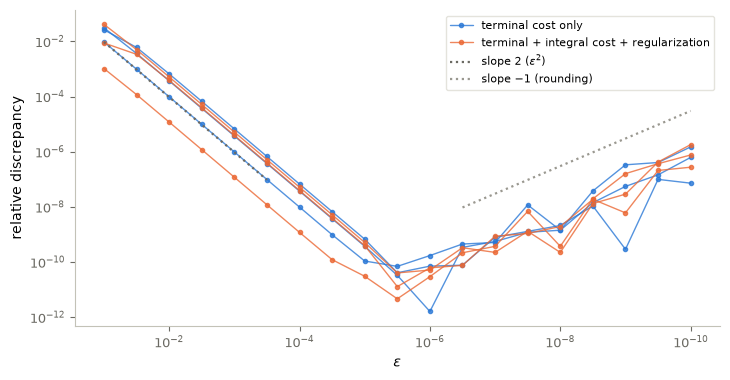

In [5]:
# E6: the two-class point cloud of notebooks 00 and 09-11, with its fixed split.
# The E6 test split was evaluated in notebook 11 and is not used here.
X6 = torch.cat([torch.randn(60, 2) * 0.45 + torch.tensor([-0.6, 0.0]),
                torch.randn(60, 2) * 0.45 + torch.tensor([1.3, 0.3])]).numpy()
y6 = np.repeat([0.0, 1.0], 60)
idx6 = rng.permutation(len(y6))
train6, val6, test6 = idx6[:72], idx6[72:96], idx6[96:]
X_tr, y_tr, X_val, y_val = X6[train6], y6[train6], X6[val6], y6[val6]

expit = lambda z: 1 / (1 + np.exp(-z))

def half_plane_logistic(scale=4.0):
    # terminal cost Phi_n(x) = log(1 + e^z) - y_n z with z = scale (x1 - 1), and its gradient in x
    def Phi(y):
        return lambda X: np.logaddexp(0, scale * (X[:, 0] - 1)) - y * scale * (X[:, 0] - 1)
    def dPhi(y):
        def grad(X):
            out = np.zeros_like(X)
            out[:, 0] = scale * (expit(scale * (X[:, 0] - 1)) - y)
            return out
        return grad
    return Phi, dPhi

def objective(X0, Theta, h, Phi_term, run=None, alpha=0.0):
    xs = euler_flow(X0, Theta, h)
    J = Phi_term(xs[-1]).mean()
    if run is not None:
        J += h * sum(run(x).mean() for x in xs[:-1])
    return J + alpha * h * sum(np.sum(W**2) + np.sum(A**2) + np.sum(b**2) for W, A, b in zip(*Theta))

def discrete_adjoint(X0, Theta, h, dPhi_term, drun=None, alpha=0.0, counts=None):
    # exact gradient of the discrete cost: forward states, backward adjoints, gradient layer by layer
    Ws, As, bs = Theta
    xs = euler_flow(X0, Theta, h)
    n, K = len(X0), len(bs)
    p = dPhi_term(xs[-1]) / n                                         # p_K
    gW, gA, gb = [], [], []
    for k in reversed(range(K)):
        x, W, A, b = xs[k], Ws[k], As[k], bs[k]
        z = x @ A.T + b
        s, ds = np.tanh(z), 1 - np.tanh(z) ** 2
        Wp = ds * (p @ W)                                             # sigma'(z) ⊙ W^T p, one row per sample
        gW.append(h * p.T @ s + 2 * alpha * h * W)                    # these use p_{k+1} ...
        gA.append(h * Wp.T @ x + 2 * alpha * h * A)
        gb.append(h * Wp.sum(0) + 2 * alpha * h * b)
        p = p + h * (Wp @ A)                                          # ... and this produces p_k
        if drun is not None:
            p = p + h * drun(x) / n
    if counts is not None:
        counts["field"] = counts.get("field", 0) + n * K
        counts["vjp"] = counts.get("vjp", 0) + n * K
    return (np.array(gW[::-1]), np.array(gA[::-1]), np.array(gb[::-1])), xs, p

pack = lambda Theta: np.concatenate([t.ravel() for t in Theta])

Theta_chk, h_chk = piecewise_constant(pieces_fix, 2), T_fix / (2 * M)     # K = 8 layers of the fixed control
Phi, dPhi = half_plane_logistic(4.0)
costs = {"terminal cost only": (None, None, 0.0),
         "terminal + integral cost + regularization": (Phi(y_tr), dPhi(y_tr), 0.01)}
directions = [tuple(rng.normal(size=t.shape) for t in Theta_chk) for _ in range(3)]
eps_grid = np.logspace(-1, -10, 19)
check = {}
for name, (run, run_grad, alpha) in costs.items():
    counts = {}
    grad, _, _ = discrete_adjoint(X_tr, Theta_chk, h_chk, dPhi(y_tr), run_grad, alpha, counts=counts)
    J = lambda Th: objective(X_tr, Th, h_chk, Phi(y_tr), run, alpha)
    rel = np.zeros((len(directions), len(eps_grid)))
    for i, v in enumerate(directions):
        exact = sum(np.sum(g * d) for g, d in zip(grad, v))
        for j, e in enumerate(eps_grid):
            central = (J(tuple(t + e * d for t, d in zip(Theta_chk, v)))
                       - J(tuple(t - e * d for t, d in zip(Theta_chk, v)))) / (2 * e)
            rel[i, j] = abs(central - exact) / abs(exact)
    check[name] = rel
    print(f"{name:42s} smallest relative discrepancy per direction: " + ", ".join(
        f"{r.min():.1e} (eps = {eps_grid[r.argmin()]:.0e})" for r in rel))
    print(f"{'':42s} adjoint gradient cost: {counts['field']} field evaluations + {counts['vjp']} vector-Jacobian products")
n_par = pack(Theta_chk).size
print(f"|Theta| = {n_par}: a central-difference gradient needs {2 * n_par} forward passes = "
      f"{2 * n_par * len(X_tr) * len(Theta_chk[2])} field evaluations")

fig, ax = P.panels(figsize=(7.4, 3.9))
for (name, rel), c in zip(check.items(), (P.BLUE, P.ORANGE)):
    for i, r in enumerate(rel):
        ax.loglog(eps_grid, r, "o-", ms=3, lw=1, color=c, alpha=0.8, label=name if i == 0 else None)
ax.loglog(eps_grid[:6], check["terminal cost only"][0, 0] * (eps_grid[:6] / eps_grid[0]) ** 2, ":",
          color=P.NOTE, label=r"slope 2 ($\varepsilon^2$)")
ax.loglog(eps_grid[-8:], 1e-16 / eps_grid[-8:] * 30, ":", color=P.GREY, label=r"slope $-1$ (rounding)")
ax.invert_xaxis()
P.label(ax, r"$\varepsilon$", "relative discrepancy")
plt.show()

**Figure 3.** The discrete adjoint against central differences on the E6 training points, for the two costs, along three random directions each: relative discrepancy between $\langle\nabla J,v\rangle$ and $\big(J(\Theta+\varepsilon v)-J(\Theta-\varepsilon v)\big)/2\varepsilon$ as $\varepsilon$ decreases (left to right), with guides of slopes $2$ and $-1$.

*Interpretation (answer to the prediction).* The curves have the V shape of notebook 07. For large $\varepsilon$ the discrepancy is the truncation error of the central difference, decreasing like $\varepsilon^2$. For small $\varepsilon$, rounding errors divided by $\varepsilon$ take over. The minimum, near $\varepsilon\approx10^{-6}$, is about $10^{-10}$ or below (printed): the accuracy observed in this experiment, set by the balance of truncation and rounding errors, not a universal limit. The adjoint gradient is therefore exact up to rounding, for the terminal cost alone and with the integral cost and the regularization included. It costs one forward and one backward pass; the finite-difference gradient would cost the number of forward passes printed.

## 6. Laboratory: learning a dynamics from trajectories

So far the control was fixed by hand. The first trained example is **system identification**: recover the law of motion behind an observed trajectory. The right-hand side is a small MLP,
$$
\dot x = f_\theta(x), \qquad f_\theta : \mathbb{R}^3 \to \mathbb{R}^3,
$$
which can approximate continuous vector fields on compact sets (Hornik, 1991). Training fits this vector field so that the trajectories it generates match the data: the loss is a mean squared error over short trajectory windows, differentiated through the RK4 solver by PyTorch's reverse-mode automatic differentiation — which is exactly the discrete adjoint of §5, assembled for us by the framework, stage by stage of the solver.

As training data we take one noisy Lorenz trajectory (2000 steps of $h=0.01$, observation noise $0.1$); the state is normalized and the time rescaled before fitting.

In [6]:
class VectorField(nn.Module):
    # the neural ODE ansatz: an MLP playing the role of the right-hand side
    def __init__(self, dim=2, width=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(dim, width), nn.Tanh(),
                                 nn.Linear(width, width), nn.Tanh(),
                                 nn.Linear(width, dim))
    def forward(self, t, x):                    # same signature as every f used by odeint
        return self.net(x)

ts_lor = torch.linspace(0, 20, 2001)            # h = 0.01
with torch.no_grad():
    x_lor = odeint(f_lorenz, torch.tensor([1.0, 1.0, 1.0]), ts_lor)
    x_lor = x_lor + 0.1 * torch.randn_like(x_lor)

# Rescaled system: normalized state z = (x - mu) / sd, new time tau = 10 * t
mu, sd = x_lor.mean(0), x_lor.std(0)
z_lor, taus = (x_lor - mu) / sd, 10.0 * ts_lor

f_theta = VectorField(dim=3, width=128)
optimizer = torch.optim.Adam(f_theta.parameters(), lr=3e-3)

SEG, BATCH = 10, 64                             # windows of 10 steps = 0.1 time units
for it in range(2001):
    for g in optimizer.param_groups:
        g["lr"] = 3e-3 * (1 - it / 2000)        # decay the step size linearly to zero
    i0 = torch.randint(0, len(taus) - SEG, (BATCH,))
    target = z_lor[i0[:, None] + torch.arange(SEG + 1)]
    pred = odeint(f_theta, z_lor[i0], taus[: SEG + 1])
    L = torch.mean((pred.transpose(0, 1) - target) ** 2)              # mean squared error over the window
    optimizer.zero_grad()
    L.backward()
    optimizer.step()
    if it % 500 == 0:
        print(f"iteration {it:4d}:  loss = {L.item():.4f}")

iteration    0:  loss = 0.2329


iteration  500:  loss = 0.0011


iteration 1000:  loss = 0.0006


iteration 1500:  loss = 0.0005


iteration 2000:  loss = 0.0005


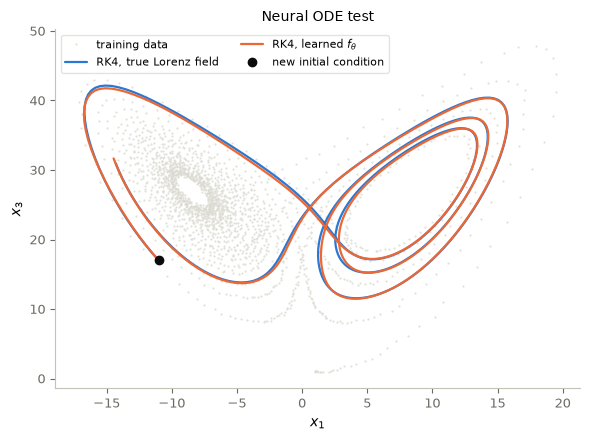

In [7]:
x0_new = torch.tensor([-11.0, -19.0, 17.0])     # near the attractor, but not a training point
ts_new = torch.linspace(0, 3, 501)
with torch.no_grad():
    tr_true = odeint(f_lorenz, x0_new, ts_new)                        # ground truth: RK4 on the true field
    tr_hat = mu + sd * odeint(f_theta, (x0_new - mu) / sd, 10 * ts_new)   # learned field, mapped back

fig, ax = P.panels(figsize=(6, 4.5))
ax.plot(x_lor[:, 0], x_lor[:, 2], ".", color=P.GHOST, ms=1, label="training data")
ax.plot(tr_true[:, 0], tr_true[:, 2], color=P.BLUE, label="RK4, true Lorenz field")
ax.plot(tr_hat[:, 0], tr_hat[:, 2], color=P.ORANGE, label=r"RK4, learned $f_\theta$")
ax.plot(x0_new[0], x0_new[2], "o", color=P.INK, ms=6, label="new initial condition")
P.label(ax, "$x_1$", "$x_3$", "Neural ODE test", legend={"loc": "upper left", "ncol": 2})
plt.show()

**Figure 4.** A neural ODE trained on one noisy Lorenz trajectory (grey dots), then integrated from a new initial condition and compared with the true flow. The learned trajectory follows the true one closely at first and stays on the attractor afterwards — exact long-term agreement is impossible on a chaotic system, where even the exact flow from a perturbed initial condition diverges. Learning a dynamics from trajectory data returns in [notebook 16](16_neural_transport.ipynb), where the trajectories transport a whole distribution.

## 7. Laboratory: a residual classifier for E6

**The task.** E6 is the two-class point cloud of notebooks 09–11, labels $0$ and $1$. The **readout is fixed and has no trained parameter**: a point is labelled $1$ if the first coordinate of its final state exceeds $1$, and $0$ otherwise, i.e. $\Omega_1=\{x^{(1)}>1\}$, $\Omega_0=\{x^{(1)}<1\}$. All the work is done by the flow, which must carry each training point into the region of its label: classification as simultaneous control. The terminal cost is the logistic loss $\Phi_n(x)=\log(1+e^{z})-y^nz$ with $z=4(x^{(1)}-1)$. Its gradient pushes each point across the line $x^{(1)}=1$, towards its side.

**Protocol** (fixed before this laboratory was run).

- **Data:** the E6 training split (72 points) for training and the validation split (24) for the choice. The E6 test split was evaluated in notebook 11 and is not used.
- **Model:** width $P=8$, $\tanh$, $T=2$; deterministic initialization (all $W_k=0$, so the network starts as the identity map; inner normals equally spaced on a half-circle; biases spread in $[-0.5,0.5]$).
- **Training:** full-batch Adam of notebook 11 ($\eta=0.05$, $1000$ steps), with exact gradients from the discrete adjoint of §5.
- **Choice on validation data:** the depth $K\in\{5,10,20\}$, i.e. refinement at the fixed horizon $T=2$, and the regularization $\alpha\in\{0,10^{-3},10^{-2},10^{-1}\}$, by the smallest validation mean logistic loss.
- **Final evaluation: none in this notebook.** The protocol registers a **joint final evaluation** of this classifier and of the constructed controls of notebook 14, on new independent observations of the E6 population law, applied only once both procedures are frozen. **At the end of this notebook it is pending**; it is applied and reported in [notebook 14](14_classification_simultaneous_control.ipynb).

> **Predict.** Will the validation choice prefer no regularization? What will the network do to the point cloud? Is the trained network map guaranteed to be an invertible deformation of the plane, as the flow of an ODE would be?

In [8]:
def init_theta(K, P_width, d=2):
    # deterministic start: W = 0 (identity network), normals equally spaced on a half-circle, biases spread
    Ws = np.zeros((K, d, P_width))
    ang = np.pi * (np.arange(P_width) + 0.5) / P_width - np.pi / 2
    As = np.tile(np.stack([np.cos(ang), np.sin(ang)], axis=1), (K, 1, 1))
    bs = np.tile(np.linspace(-0.5, 0.5, P_width), (K, 1))
    return Ws, As, bs

def train_classifier(X, y, K, alpha, P_width=8, T=2.0, n_steps=1000, eta=0.05, scale=4.0, counts=None):
    # full-batch Adam on the packed parameters, exact adjoint gradients
    h = T / K
    Phi_c, dPhi_c = half_plane_logistic(scale)
    Theta = init_theta(K, P_width)
    shapes = [t.shape for t in Theta]
    sizes = [t.size for t in Theta]
    unpack = lambda flat: tuple(seg.reshape(sh) for seg, sh in zip(np.split(flat, np.cumsum(sizes)[:-1]), shapes))
    flat = pack(Theta)
    m, v = np.zeros_like(flat), np.zeros_like(flat)
    for k in range(1, n_steps + 1):
        grads, _, _ = discrete_adjoint(X, unpack(flat), h, dPhi_c(y), None, alpha, counts=counts)
        g = pack(grads)
        m, v = 0.9 * m + 0.1 * g, 0.999 * v + 0.001 * g * g
        flat = flat - eta * (m / (1 - 0.9 ** k)) / (np.sqrt(v / (1 - 0.999 ** k)) + 1e-8)
    return unpack(flat), h

readout_label = lambda X: (X[:, 0] > 1).astype(float)
mean_loss = lambda X, y, Theta, h: half_plane_logistic(4.0)[0](y)(euler_flow(X, Theta, h)[-1]).mean()
accuracy = lambda X, y, Theta, h: np.mean(readout_label(euler_flow(X, Theta, h)[-1]) == y)

depths, alphas = [5, 10, 20], [0.0, 1e-3, 1e-2, 1e-1]
train_counts, models, table = {}, {}, {}
for K in depths:
    for alpha in alphas:
        Theta_m, h_m = train_classifier(X_tr, y_tr, K, alpha, counts=train_counts)
        models[(K, alpha)] = (Theta_m, h_m)
        table[(K, alpha)] = {"train loss": mean_loss(X_tr, y_tr, Theta_m, h_m),
                             "train accuracy": accuracy(X_tr, y_tr, Theta_m, h_m),
                             "validation loss": mean_loss(X_val, y_val, Theta_m, h_m),
                             "validation accuracy": accuracy(X_val, y_val, Theta_m, h_m)}
best = min(table, key=lambda ka: table[ka]["validation loss"])
print("   K    alpha    train loss   train acc.   validation loss   validation acc.")
for (K, alpha), row in table.items():
    mark = "  <- selected" if (K, alpha) == best else ""
    print(f"{K:4d}  {alpha:7.0e}   {row['train loss']:10.4f}   {row['train accuracy']:9.3f}   "
          f"{row['validation loss']:15.4f}   {row['validation accuracy']:15.3f}{mark}")
Theta13, h13 = models[best]
print(f"training cost of the whole grid ({len(table)} trainings x 1000 Adam steps): "
      f"{train_counts['field']:,} field evaluations and {train_counts['vjp']:,} vector-Jacobian products")

   K    alpha    train loss   train acc.   validation loss   validation acc.
   5    0e+00       0.0000       1.000            0.0000             1.000
   5    1e-03       0.0004       1.000            0.0021             1.000
   5    1e-02       0.0047       1.000            0.0113             1.000
   5    1e-01       0.0383       1.000            0.0694             0.958
  10    0e+00       0.0000       1.000            0.0000             1.000
  10    1e-03       0.0004       1.000            0.0019             1.000
  10    1e-02       0.0045       1.000            0.0107             1.000
  10    1e-01       0.0374       1.000            0.0681             0.958
  20    0e+00       0.0000       1.000            0.0000             1.000  <- selected
  20    1e-03       0.0004       1.000            0.0018             1.000
  20    1e-02       0.0043       1.000            0.0105             1.000
  20    1e-01       0.0370       1.000            0.0674             0.958
training c

h ||W_k|| ||A_k|| per layer: [0.53 0.51 0.5  0.48 0.46 0.45 0.43 0.42 0.4  0.39 0.38 0.37 0.36 0.35
 0.34 0.33 0.32 0.32 0.31 0.29]
smallest det(I + h D_x f) over the layers and the plotted region: 0.9243


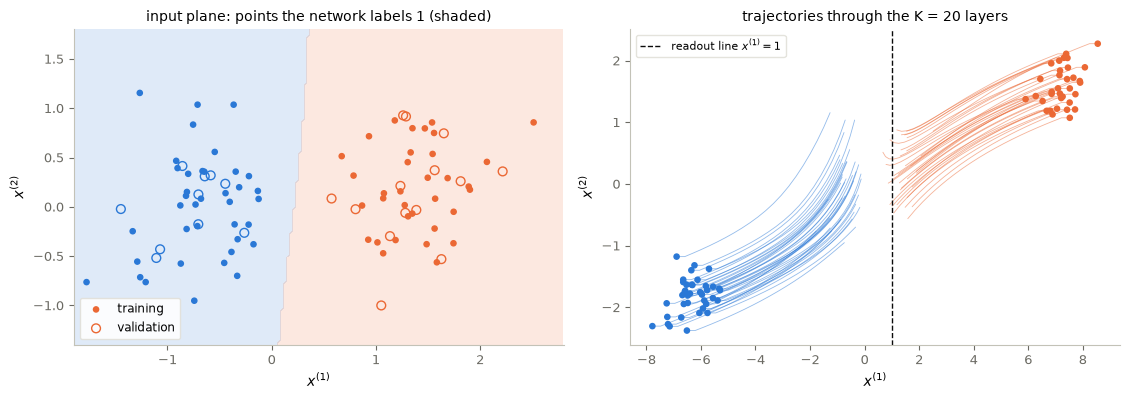

In [9]:
g1, g2 = np.meshgrid(np.linspace(-1.9, 2.8, 170), np.linspace(-1.4, 1.8, 120))
traj_grid = euler_flow(np.column_stack([g1.ravel(), g2.ravel()]), Theta13, h13)
region = readout_label(traj_grid[-1]).reshape(g1.shape)
traj = euler_flow(X_tr, Theta13, h13)

# Is each layer x -> x + h f(x, theta_k) invertible? Sufficient: h ||W_k|| ||A_k|| < 1.
# Necessary for a local orientation-preserving diffeomorphism: det(I + h D_x f) > 0 along the trajectories.
W13, A13, b13 = Theta13
step_lip = np.array([h13 * np.linalg.norm(W, 2) * np.linalg.norm(A, 2) for W, A in zip(W13, A13)])
det_min = np.inf
for k in range(len(b13)):
    S = 1 - np.tanh(traj_grid[k] @ A13[k].T + b13[k]) ** 2            # sigma'(z) along every grid trajectory
    Jac = np.eye(2) + h13 * np.einsum("dp,np,pe->nde", W13[k], S, A13[k])
    det_min = min(det_min, (Jac[:, 0, 0] * Jac[:, 1, 1] - Jac[:, 0, 1] * Jac[:, 1, 0]).min())
print("h ||W_k|| ||A_k|| per layer:", step_lip.round(2))
print(f"smallest det(I + h D_x f) over the layers and the plotted region: {det_min:.4f}")

colors = np.where(y_tr == 1, P.ORANGE, P.BLUE)
fig, (ax1, ax2) = P.panels(2, figsize=(11.4, 4.1))
ax1.contourf(g1, g2, region, levels=[-0.5, 0.5, 1.5], colors=[P.BLUE, P.ORANGE], alpha=0.15)
ax1.scatter(X_tr[:, 0], X_tr[:, 1], c=colors, s=14, label="training")
ax1.scatter(X_val[:, 0], X_val[:, 1], facecolors="none",
            edgecolors=np.where(y_val == 1, P.ORANGE, P.BLUE), s=40, label="validation")
P.label(ax1, "$x^{(1)}$", "$x^{(2)}$", title="input plane: points the network labels 1 (shaded)",
        legend={"fontsize": 8.5, "loc": "lower left"})
for n in range(len(X_tr)):
    ax2.plot(traj[:, n, 0], traj[:, n, 1], color=colors[n], lw=0.6, alpha=0.5)
ax2.scatter(traj[-1, :, 0], traj[-1, :, 1], c=colors, s=14)
ax2.axvline(1.0, color=P.INK, lw=1, ls="--", label=r"readout line $x^{(1)}=1$")
P.label(ax2, "$x^{(1)}$", "$x^{(2)}$", title=f"trajectories through the K = {best[0]} layers")
plt.show()

**Figure 5.** The residual classifier chosen on validation data. *Left:* the input plane, shaded where the network predicts label $1$ (the preimage of $\Omega_1$ under the network map), with the training points (filled) and validation points (open), coloured by their true labels. *Right:* the trajectories of the training points through the layers, and the readout line $x^{(1)}=1$.

*Interpretation (answer to the prediction).* On this well-separated cloud the validation choice (printed) falls on the **unregularized** model: every candidate with $\alpha\le10^{-2}$ classifies all 24 validation points correctly, the logistic loss keeps rewarding larger margins, and the unpenalized flow, which pushes the two classes far from the readout line (right panel), attains the smallest validation loss — the three depths tie to printed precision. That is a property of this easy task, not a general rule; with noisier data the control cost wins the validation choice. **Whether the trained network is a flow must be checked, not assumed:** here the printed step sizes satisfy $h\|W_k\|\|A_k\|<1$ on every layer and the smallest Jacobian determinant of a layer is positive, so this particular network is certifiably an invertible deformation of the plane. That is a certificate for this run, not a guarantee: training did not ask for small steps, and with other data or initialization a trained ResNet can fold the plane, which no flow of an ODE can do (§1). How well this classifier does on *new* observations is exactly what has not yet been measured: the joint evaluation is pending.

## 8. Learning representations: the flow deforms the plane

The E6 cloud needs only a gentle flow. To see a neural ODE do real geometric work we take the **two-moons** data — two interleaved half-circles, which no straight line can separate — and train both the field *and* an affine readout:
$$
\text{logits}(x_{\text{in}}) := W\, x(1) + b, \qquad \dot x = f_\theta(x), \quad x(0) = x_{\text{in}},
$$
with the cross-entropy loss. The final layer separates the classes with a **straight line**, so all of the geometric work has to be done by the flow: it must *deform the plane* until the two sets of points become linearly separable. This time the training is pure PyTorch — reverse-mode automatic differentiation through ten RK4 steps — the practice whose theory is §5.

In [10]:
def make_moons(n_per_class=200, noise=0.08):
    t = np.pi * rng.random(n_per_class)
    upper = np.stack([np.cos(t), np.sin(t)], axis=1)                  # class 0
    lower = np.stack([1 - np.cos(t), 0.5 - np.sin(t)], axis=1)        # class 1
    X = np.concatenate([upper, lower]) + noise * rng.standard_normal((2 * n_per_class, 2))
    y = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)]).astype(np.int64)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y)

X_data, y_data = make_moons()
perm = torch.randperm(len(X_data))
tr_idx, te_idx = perm[:300], perm[300:]              # 75% train / 25% test

flow_field = VectorField(width=32)                   # the flow's right-hand side
head = nn.Linear(2, 2)                               # affine readout on x(1)
ts_flow = torch.linspace(0, 1, 11)                   # T = 1, ten RK4 steps

def logits(x):
    return head(odeint(flow_field, x, ts_flow)[-1])

optimizer = torch.optim.Adam(list(flow_field.parameters()) + list(head.parameters()), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

for it in range(501):
    L = loss_fn(logits(X_data[tr_idx]), y_data[tr_idx])
    optimizer.zero_grad()
    L.backward()
    optimizer.step()
    if it % 100 == 0:
        with torch.no_grad():
            acc = (logits(X_data[te_idx]).argmax(dim=1) == y_data[te_idx]).float().mean()
        print(f"iteration {it:3d}:  loss = {L.item():.4f},  test accuracy = {acc:.1%}")

iteration   0:  loss = 1.0411,  test accuracy = 15.0%


iteration 100:  loss = 0.0011,  test accuracy = 100.0%


iteration 200:  loss = 0.0003,  test accuracy = 100.0%


iteration 300:  loss = 0.0001,  test accuracy = 100.0%


iteration 400:  loss = 0.0001,  test accuracy = 100.0%


iteration 500:  loss = 0.0000,  test accuracy = 100.0%


In [11]:
# The trajectory of EVERY data point under the learned flow
with torch.no_grad():
    flow_traj = odeint(flow_field, X_data, torch.linspace(0, 1, 41)).numpy()   # (41, 400, 2)
    w = (head.weight[0] - head.weight[1]).numpy()                              # readout boundary w·x + b = 0
    b = (head.bias[0] - head.bias[1]).item()
colors = np.where(y_data.numpy() == 0, P.BLUE, P.ORANGE)

def readout_boundary(ax):
    x1 = np.array(ax.get_xlim())
    ax.plot(x1, -(w[0] * x1 + b) / w[1], "--", color=P.INK, lw=1.5)

P.animate_points(flow_traj, color=colors, decorate=readout_boundary, equal=False,
                 figsize=(5.5, 4), xlabel="$x_1$", ylabel="$x_2$",
                 title=lambda k: f"flow at $t = {k / 40:.2f}$", interval=120)

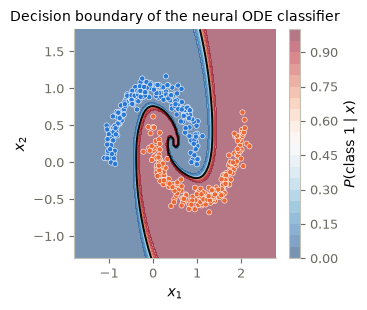

In [12]:
# Decision boundary back in INPUT space: grid points are flowed forward, then classified
g1, g2 = np.meshgrid(np.linspace(-1.8, 2.8, 120), np.linspace(-1.3, 1.8, 120))
grid = torch.tensor(np.stack([g1.ravel(), g2.ravel()], axis=1), dtype=torch.float32)
with torch.no_grad():
    probs = torch.softmax(logits(grid), dim=1)[:, 1].reshape(g1.shape).numpy()

fig, ax = P.panels()
P.decision_boundary(ax, g1, g2, probs, X_data, y_data,
                    title="Decision boundary of the neural ODE classifier")
plt.show()

**Figure 6.** *Animation:* every two-moons point carried by the learned flow from $t=0$ to $t=1$; the dashed line is the fixed readout boundary in the final space. *Below:* the resulting decision boundary pulled back to the input plane — the preimage of a straight line under the flow is a curve that wraps around the moons.

*Interpretation.* The flow untangles the two half-moons until a single straight line separates them: the network classifies by **changing the representation**, not by drawing a complicated boundary directly. This is the dictionary of notebook 00 read off a computation: state = representation, trajectory = forward pass, depth = time.

## 9. Control ↔ ML

- **Residual network = Euler scheme of a controlled ODE.** **DIRECT CONNECTION.** Layers are time steps, parameters are controls, a forward pass is a trajectory. The approximation statement holds at a fixed horizon, under (H1)–(H2).
- **Backpropagation = the discrete adjoint.** **DIRECT CONNECTION** (notebook 07). The same state–adjoint–gradient structure, exact for the discrete cost; frameworks like PyTorch assemble it automatically (§6, §8).
- **$L^2$ regularization of the parameters = quadratic control cost.** **DIRECT CONNECTION.** The term $\alpha\int\|(a,w,b)\|^2$ is the $L^2$ control cost of notebooks 02–08 (as a penalty in the loss; decoupled weight decay, as in AdamW, is a different update, §4), and without it the horizon can be absorbed into the size of the controls.
- **Classification = simultaneous control.** **DIRECT CONNECTION.** One control for all data points. [Notebook 14](14_classification_simultaneous_control.ipynb) constructs such controls explicitly instead of training them.
- **Depth and long horizons.** **MATHEMATICAL ANALOGY** with notebook 08. Adding layers at a fixed step is a long-horizon problem, the setting where turnpike phenomena are studied (§12). It is not a theorem about trained networks.

## 10. Common misconceptions

**"A deeper ResNet is always a finer discretization of a neural ODE."** Only if the horizon is fixed and the layers sample one control. Adding layers at a fixed step lengthens the horizon instead (§1, Figure 2), and a trained network's layers need not vary regularly at all.

**"Backpropagation is a different algorithm from the adjoint method."** It is the discrete adjoint: the same recursion, exact for the discrete cost (§5).

**"The gradient of the discretized cost is the discretization of the continuous gradient."** Not necessarily. It depends on how the continuous adjoint is discretized: a compatible discretization reproduces the discrete adjoint exactly, while the natural choice of §11 differs from it, by an amount observed to be of order $h$ in our example. Optimizing the discrete network needs the gradient of the discrete cost.

**"Finite differences are a reliable way to get gradients."** They cost $2|\Theta|$ forward passes, and in our experiment they were accurate to about $10^{-10}$ at the best $\varepsilon$, limited by truncation for large $\varepsilon$ and by rounding for small $\varepsilon$ (Figure 3). They are a *test* of the gradient, not a way to compute it.

**"The horizon $T$ is a hyperparameter like any other."** At a fixed number of layers and without a control cost it can be absorbed into the weights (§1).

**"A training accuracy of 100% means the classifier is good."** It says nothing about new observations; that is what the frozen final evaluation is for (§7).

## 11. The continuous adjoint, and order preservation in one dimension

**Differentiate, then discretize.** For the continuous problem $x'=f(x,\theta(t))$ with cost $\frac1N\sum_n\big[\Phi_n(x^n(T))+\int_0^T\ell_n(x^n)dt\big]+\alpha\int_0^T|\theta|^2dt$, the same Lagrangian argument gives the **continuous adjoint system**
$$
-p^{n\,\prime}(t)=D_xf(x^n(t),\theta(t))^{\top}p^n(t)+\tfrac1N\nabla\ell_n(x^n(t)),\qquad p^n(T)=\tfrac1N\nabla\Phi_n(x^n(T)),
$$
and the gradient $\nabla_{\theta(t)}J=\sum_nD_\theta f(x^n,\theta)^\top p^n+2\alpha\theta(t)$ — the structure $-\varphi'=A^*\varphi$, $\nabla J=u+B^*\varphi$ of notebook 07. One can discretize this system instead of differentiating the discrete one. A natural choice integrates the adjoint backward by explicit Euler from $t_{k+1}$ to $t_k$, with the Jacobian at $x_{k+1}$, and uses $p_k$ in the gradient on $[t_k,t_{k+1})$. Both gradients converge to the gradient of the continuous problem as $h\to0$, but for this choice **they are not equal**: the continuous version is not the exact gradient of the discrete cost. A compatible discretization, one that reproduces the backward recursion of §5, would coincide with it. In the example below their relative difference is observed to decrease like $h$. The cell measures it for the piecewise-constant control of Laboratory 1, refined at fixed horizon; the gradients are taken with respect to the four piece values, so that they can be compared across meshes.

     h      |g_disc - g_cont| / |g_disc|   discrete vs central diff.   continuous vs central diff.
 0.50000                  4.085e-01                     1.4e-10                     5.707e-01
 0.25000                  1.831e-01                     3.3e-10                     2.473e-01
 0.12500                  8.662e-02                     4.4e-10                     1.173e-01
 0.06250                  4.226e-02                     4.8e-10                     5.757e-02
 0.03125                  2.090e-02                     5.5e-10                     2.858e-02
 0.01562                  1.040e-02                     5.4e-10                     1.424e-02
 0.00781                  5.187e-03                     4.4e-10                     7.112e-03


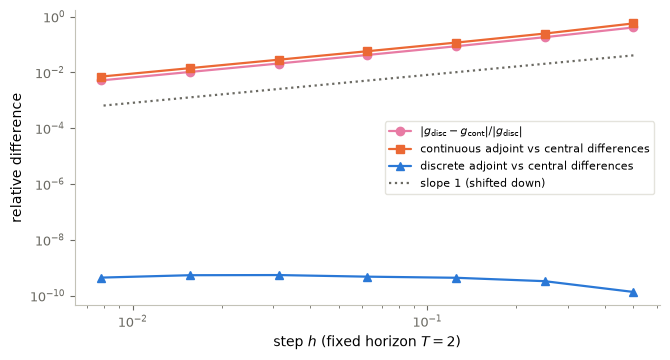

In [13]:
def continuous_adjoint_gradient(X0, Theta, h, dPhi_term, drun=None, alpha=0.0):
    # differentiate-then-discretize: backward Euler steps of the continuous adjoint (Jacobian at x_{k+1}),
    # gradient on [t_k, t_{k+1}) with p_k — NOT the exact gradient of the discrete cost
    Ws, As, bs = Theta
    xs = euler_flow(X0, Theta, h)
    n, K = len(X0), len(bs)
    p = dPhi_term(xs[-1]) / n
    gW, gA, gb = [], [], []
    for k in reversed(range(K)):
        x1 = xs[k + 1]
        Wp1 = (1 - np.tanh(x1 @ As[k].T + bs[k]) ** 2) * (p @ Ws[k])
        p = p + h * (Wp1 @ As[k])
        if drun is not None:
            p = p + h * drun(x1) / n
        x = xs[k]
        z = x @ As[k].T + bs[k]
        s, ds = np.tanh(z), 1 - np.tanh(z) ** 2
        Wp = ds * (p @ Ws[k])
        gW.append(h * p.T @ s + 2 * alpha * h * Ws[k])
        gA.append(h * Wp.T @ x + 2 * alpha * h * As[k])
        gb.append(h * Wp.sum(0) + 2 * alpha * h * bs[k])
    return (np.array(gW[::-1]), np.array(gA[::-1]), np.array(gb[::-1]))

def sum_over_pieces(grads, substeps):
    # total gradient with respect to each PIECE value: sum the per-layer gradients within each piece
    return tuple(g.reshape(-1, substeps, *g.shape[1:]).sum(axis=1) for g in grads)

v_pieces = tuple(rng.normal(size=p_.shape) for p_ in pieces_fix)      # one direction in the piece values
Phi_run, dPhi_run = Phi(y_tr), dPhi(y_tr)
rows = []
for s in (1, 2, 4, 8, 16, 32, 64):
    Th, h = piecewise_constant(pieces_fix, s), T_fix / (M * s)
    g_disc = sum_over_pieces(discrete_adjoint(X_tr, Th, h, dPhi(y_tr), dPhi_run, 0.01)[0], s)
    g_cont = sum_over_pieces(continuous_adjoint_gradient(X_tr, Th, h, dPhi(y_tr), dPhi_run, 0.01), s)
    J = lambda P_: objective(X_tr, piecewise_constant(P_, s), h, Phi(y_tr), Phi_run, 0.01)
    e = 1e-5
    central = (J(tuple(p_ + e * d for p_, d in zip(pieces_fix, v_pieces)))
               - J(tuple(p_ - e * d for p_, d in zip(pieces_fix, v_pieces)))) / (2 * e)
    dot = lambda g: sum(np.sum(a * b) for a, b in zip(g, v_pieces))
    rows.append((h, np.linalg.norm(pack(g_disc) - pack(g_cont)) / np.linalg.norm(pack(g_disc)),
                 abs(dot(g_disc) - central) / abs(central), abs(dot(g_cont) - central) / abs(central)))
rows = np.array(rows)
print("     h      |g_disc - g_cont| / |g_disc|   discrete vs central diff.   continuous vs central diff.")
for r in rows:
    print(f"{r[0]:8.5f}   {r[1]:24.3e}   {r[2]:25.1e}   {r[3]:27.3e}")

fig, ax = P.panels(figsize=(6.8, 3.7))
ax.loglog(rows[:, 0], rows[:, 1], "o-", color=P.MAGENTA, label=r"$|g_{\rm disc}-g_{\rm cont}|/|g_{\rm disc}|$")
ax.loglog(rows[:, 0], rows[:, 3], "s-", color=P.ORANGE, label="continuous adjoint vs central differences")
ax.loglog(rows[:, 0], np.maximum(rows[:, 2], 1e-16), "^-", color=P.BLUE, label="discrete adjoint vs central differences")
ax.loglog(rows[:, 0], 0.1 * rows[0, 1] * rows[:, 0] / rows[0, 0], ":", color=P.NOTE, label="slope 1 (shifted down)")
P.label(ax, "step $h$ (fixed horizon $T=2$)", "relative difference")
plt.show()

**Figure 7.** Discretize-then-differentiate against differentiate-then-discretize, for the four piece values of the fixed control of Laboratory 1 and the cost of Laboratory 2 (ii), as $h$ is refined at $T=2$. Shown: the relative difference between the two gradients, and the discrepancy of each with central differences of the *discrete* cost along one direction.

*Interpretation.* The discrete adjoint agrees with central differences of the discrete cost to the accuracy of the check at every $h$, because it is the exact gradient of that cost. The discretized continuous adjoint is off by an amount that decreases like $h$, as does its distance to the discrete gradient. Both converge to the gradient of the continuous problem, but only one of them is the gradient of the function that is actually being minimized. For a gradient method with a fixed mesh this matters: with an inexact gradient, the iteration can stall or wander at the level of the $O(h)$ error.

**Order preservation in one dimension.** For a scalar ODE $x'=f(x,\theta(t))$ with (H1), two solutions with $x(0)<y(0)$ satisfy $x(t)<y(t)$ for all $t$: if they met, uniqueness of solutions would force them to coincide forever. **The exact flow of a scalar neural ODE preserves order**, so no one-dimensional neural ODE can map $0<1$ to $1>0$, whatever the control (this restriction reappears in notebook 14). Euler inherits the property **only under a step condition**:
$$
x_{k+1}-y_{k+1}=(x_k-y_k)+h\big(f(x_k,\theta_k)-f(y_k,\theta_k)\big)\le(1+hL_f)(x_k-y_k)\quad\text{and}\quad\ge(1-hL_f)(x_k-y_k)
$$
when $x_k>y_k$, so the order is preserved if $hL_f<1$. With a large step, one Euler step of a contracting field can overshoot and swap two points. The cell below takes the neuron $f(x)=-3\tanh(x)$, so $L_f=3$, and the points $0.1<0.2$.

In [14]:
f_1d = lambda x: -3 * np.tanh(x)
pair = np.array([0.1, 0.2])
for h in (0.25, 1.0):
    after = pair + h * f_1d(pair)
    print(f"h = {h:4.2f} (h L_f = {3 * h:4.2f}): {pair} -> {np.round(after, 4)}   "
          f"order preserved: {bool(after[0] < after[1])}")

h = 0.25 (h L_f = 0.75): [0.1 0.2] -> [0.0252 0.052 ]   order preserved: True
h = 1.00 (h L_f = 3.00): [0.1 0.2] -> [-0.199  -0.3921]   order preserved: False


## 12. Turnpike and momentum: two research directions

**Turnpike for deep residual networks.** Training with a running cost on a long horizon, the "more layers at a fixed step" reading of §1, is a long-horizon optimal control problem (Geshkovski and Zuazua, 2022). The results of [notebook 08](08_long_time_control_turnpike.ipynb) were proved for linear-quadratic problems with controllability assumptions. For neural ODEs, turnpike-type statements require specific hypotheses on the cost and the dynamics, and **no universal theorem says that a trained deep network has a turnpike**. What can be observed in experiments, and what has been proved under which assumptions, must be kept apart.

**Momentum neural ODEs** replace $x'=f$ by the second-order system $x''=w(t)\sigma(a(t)\cdot x+b(t))$, the continuous analogue of momentum in optimization (notebook 11). They retain the capacity for simultaneous control with $O(N)$ neurons, and add two features: memory, and the fact that *two points can share the same position*. The state is now $(x,x')$, so trajectories may cross in position space without contradicting uniqueness, and the one-dimensional order obstruction of §11 disappears (Exercise 6). The precise hypotheses are in the cited works; they are not proved here.

## 13. Key takeaways

1. A residual network $x_{k+1}=x_k+hf(x_k,\theta_k)$ is the forward Euler scheme of a controlled ODE; parameters are controls and inputs are initial states.
2. Refining $h$ at a fixed horizon approximates one flow map with error $O(h)$, under a Lipschitz condition in the state and jumps of the control on the mesh. Adding layers at a fixed step lengthens the horizon instead.
3. At a fixed number of layers and without a control cost, the horizon can be absorbed into the weights.
4. Training is simultaneous optimal control: one control for all samples, data terms averaged, regularization counted once.
5. The discrete adjoint gives the exact gradient of the discrete cost at the price of one forward and one backward pass; it is backpropagation, and it is what PyTorch's `backward()` assembles through a solver.
6. The discretization of the continuous adjoint used in §11 gives a different gradient, observed to be about $O(h)$ away; compatible discretizations coincide with the discrete adjoint.
7. A neural ODE can learn a *dynamics* (fit the vector field to trajectories, §6) or a *representation* (deform the data until a line separates it, §8); both are trained through the same adjoint.
8. Validation chooses the depth and the control cost; only a frozen final evaluation on new observations measures generalization. For the classifier of this notebook it is still pending.

## 14. Exercises

★ conceptual · ★★ mathematical · ★★★ computational

1. **Where is $h$? ★** A ResNet is written without a step size, $x_{k+1}=x_k+g(x_k,\theta_k)$, $k=0,\dots,K-1$, with $g(x,\theta)=W\sigma(Ax+b)$. (a) For a chosen horizon $T$, write it as an Euler scheme $x_{k+1}=x_k+hf(x_k,\theta_k)$: what are $h$ and $f$? (b) Someone doubles the number of layers by repeating every layer twice, without changing the weights. Which of the two readings of §1 is this, and what happens to $T$ if $f$ is kept? (c) What must be done to the weights so that the doubled network approximates the *same* flow map?
2. **The adjoint by hand. ★★** Consider the scalar linear ResNet $x_{k+1}=(1+h\theta_k)x_k$ with $\theta_k\in\mathbb R$, one sample $x_0\ne0$, and $J=\frac12x_K^2+\alpha h\sum_k\theta_k^2$. (a) Compute $\partial J/\partial\theta_k$ directly from $x_K=x_0\prod_j(1+h\theta_j)$. (b) Write the adjoint recursion of §5 for this case and show that it gives the same result. (c) Check numerically for $K=5$.
3. **Order in one dimension. ★★** (a) Prove that one Euler step of a scalar field with Lipschitz constant $L_f$ preserves the strict order of two points when $hL_f<1$. (b) Show that the condition is sharp: for $f(x)=-cx$ ($c>0$), find the steps $h$ for which the order of two points is reversed after one step, and the step for which they collide. (c) Why can no choice of control make the *exact* flow of a scalar neural ODE reverse the order of two inputs, while a ResNet with large steps can?
4. **The price of a gradient. ★★** For the classifier selected in §7: (a) compute $|\Theta|$ and the number of field evaluations needed by one central-difference gradient on the 72 training points; (b) compare with the field evaluations plus vector–Jacobian products of one adjoint gradient, and with the whole training run of 1000 Adam steps; (c) where in the adjoint computation does the regularization enter, and what would go wrong if it were added inside the per-sample terminal cost without the average?
5. **A second-order scheme. ★★★** Heun's method replaces the Euler step by $\tilde x=x_k+hf(x_k,\theta_k)$, $x_{k+1}=x_k+\frac h2\big(f(x_k,\theta_k)+f(\tilde x,\theta_k)\big)$. (a) Implement it for the fixed control of Laboratory 1 (jumps on the mesh) and measure the observed order on nested meshes against the same reference. (b) Explain why the order would drop if a jump of the control fell inside a step, while Euler's order would not.
6. **Momentum: two points can swap. ★★★** Consider the momentum neural ODE $x''=w\sigma(ax+b)$ in one dimension with the constant control $w=-1$, $a=1$, $b=0$, $\sigma=\tanh$, i.e. $x''=-\tanh x$, starting at rest. Discretize it as the momentum ResNet $x_{k+1}=x_k+hv_k$, $v_{k+1}=v_k+hf(x_{k+1})$ with $h=0.01$. (a) Starting from $x_0=0.5$ and $x_0=1$, find a time at which their order is reversed. (b) Why does this not contradict §11? (c) Relate this to the statement that for momentum neural ODEs *two points can share the same position*.
7. **The Lorenz laboratory. ★★★** (a) Halve the time-grid spacing in Figure 1 and plot the Euler and RK4 trajectories again: how does their difference change? (b) Reduce `VectorField` in §6 to one hidden layer of width 16, retrain, and compare the trajectory from the new initial condition with the true one.
8. **Watching the representation. ★★★** For the two-moons classifier of §8, plot the data at $t=0$, halfway through the learned flow, and at the endpoint. Where do the classes become easier to separate, and what does the readout line look like in each picture?

In [15]:
# TODO: student exercise (Exercise 5)
# Same signature as euler_flow; use theta_k for both stages of step k.

def heun_flow(X0, Theta, h):
    ...  # your code here
    return None

## Where are we going?

In this notebook the control of a residual network was *trained*: gradient descent with exact adjoint gradients. [Notebook 14](14_classification_simultaneous_control.ipynb) asks the control-theoretic question behind the classifier of §7: can a neural ODE with ReLU activation steer *every* training point into the region of its label? It answers it with *constructed* piecewise-constant controls whose switches can be counted. It also runs the joint final evaluation registered here.

## References

1. K. He, X. Zhang, S. Ren, J. Sun, [*Deep residual learning for image recognition*](https://arxiv.org/abs/1512.03385), CVPR 2016.
2. R. T. Q. Chen, Y. Rubanova, J. Bettencourt, D. Duvenaud, [*Neural ordinary differential equations*](https://arxiv.org/abs/1806.07366), NeurIPS 2018.
3. W. E, [*A proposal on machine learning via dynamical systems*](https://doi.org/10.1007/s40304-017-0103-z), Communications in Mathematics and Statistics **5** (2017), 1–11.
4. D. E. Rumelhart, G. E. Hinton, R. J. Williams, [*Learning representations by back-propagating errors*](https://doi.org/10.1038/323533a0), Nature **323** (1986), 533–536.
5. E. Hairer, S. P. Nørsett, G. Wanner, [*Solving Ordinary Differential Equations I: Nonstiff Problems*](https://doi.org/10.1007/978-3-540-78862-1), 2nd ed., Springer, 1993.
6. E. N. Lorenz, [*Deterministic nonperiodic flow*](https://doi.org/10.1175/1520-0469(1963)020%3C0130:DNF%3E2.0.CO;2), Journal of the Atmospheric Sciences **20** (1963), 130–141.
7. K. Hornik, [*Approximation capabilities of multilayer feedforward networks*](https://doi.org/10.1016/0893-6080(91)90009-T), Neural Networks **4** (1991), 251–257.
8. B. Geshkovski, E. Zuazua, [*Turnpike in optimal control of PDEs, ResNets, and beyond*](https://doi.org/10.1017/S0962492922000046), Acta Numerica **31** (2022), 135–263.